In [1]:
import pathlib
import subprocess
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re
import glob
import h5py
import matplotlib.animation as animation

import scipy.special as spl
import scipy.integrate
import mpmath as mpm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fontsize_title = 22
fontsize_axis = 18
fontsize_tick = 18
fontsize_legend = 16
fontsize_cbar = 18

plt.rcParams.update({
    "font.size": fontsize_tick,
    "axes.titlesize": fontsize_title,
    "axes.labelsize": fontsize_axis,
    "xtick.labelsize": fontsize_tick,
    "ytick.labelsize": fontsize_tick,
    "legend.fontsize": fontsize_legend,
    "figure.titlesize": fontsize_title,
})

In [2]:
import os

os.getcwd()

'/net/fs06/d0/dabdulah/GFD_PROJECT/crust_convection/mantle3D_xyperiodic_lewis'

In [5]:
### GET DATA SIZES ###

with h5py.File("snapshots/snapshots_s6.h5", mode='r') as file:
    # Load datasets
    
    print('loading...')
    T_load = file['tasks']['T']
    T = np.asarray(T_load)
    print('T done')
    C = np.asarray(file['tasks']['C'])
    print('C done')
    w = np.asarray(file['tasks']['w'])
    print('w done')
    vorticity_x = np.asarray(file['tasks']['vorticity_x'])
    print('vorticity_x done')
    vorticity_y = np.asarray(file['tasks']['vorticity_y'])
    print('vorticity_y done')
    vorticity_z = np.asarray(file['tasks']['vorticity_z'])
    print('vorticity_z done')
    chf = np.asarray(file['tasks']['convective_heat_flux'])
    print('convective_heat_flux done')
    
    t = np.asarray(T_load.dims[0]['sim_time'])
    print('t done')
    
print('The data shapes are (t, nx, ny, nz)')
print(np.shape(T))

loading...
T done
C done
w done
vorticity_x done
vorticity_y done
vorticity_z done
convective_heat_flux done
t done
The data shapes are (t, nx, ny, nz)
(10, 128, 128, 64)


In [6]:
print(t)

[1.12425788 1.13954642 1.15360423 1.16690348 1.17958096 1.19169083
 1.20346471 1.21496371 1.2264627  1.2379617 ]


In [3]:
### MAKE 3D ANIMATION ###

import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# ============================================================
# Helper functions
# ============================================================

def plot_contours_on_plane(ax, A, B, F, levels, colors, plane, const, zorder=10, linewidth=0.5):
    """
    Make 2D contours of F(A,B), then draw them as 3D lines.

    plane = "xy": A=x, B=y, const=z
    plane = "xz": A=x, B=z, const=y
    plane = "yz": A=y, B=z, const=x
    """
    fig_tmp, ax_tmp = plt.subplots()
    cs = ax_tmp.contour(A, B, F, levels=levels)
    plt.close(fig_tmp)

    for ilev, segs in enumerate(cs.allsegs):
        color = colors[ilev]

        for seg in segs:
            if seg.shape[0] < 2:
                continue

            a = seg[:, 0]
            b = seg[:, 1]

            if plane == "xy":
                ax.plot(a, b, const*np.ones_like(a),
                        color=color, linewidth=linewidth,zorder=zorder)

            elif plane == "xz":
                ax.plot(a, const*np.ones_like(a), b,
                        color=color, linewidth=linewidth,zorder=zorder)

            elif plane == "yz":
                ax.plot(const*np.ones_like(a), a, b,
                        color=color, linewidth=linewidth,zorder=zorder)

def get_coord(dset, dim_index):
    keys = list(dset.dims[dim_index].keys())
    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")
    return np.asarray(dset.dims[dim_index][keys[0]])


def find_snapshot_files(snapshot_dir="snapshots", file_prefix="snapshots_s"):
    files = []
    i = 1
    while True:
        fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
        if os.path.exists(fname):
            files.append(fname)
            i += 1
        else:
            break

    if len(files) == 0:
        raise FileNotFoundError(f"No files found like {snapshot_dir}/{file_prefix}X.h5")

    return files


def make_cube_slice_animation(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    output_name="cube_slices.gif",

    C_task="C",
    C_vmin=None,
    C_vmax=None,
    C_cmap=None,
    Cscale_factor=0.8,

    z_index=-5,      # xy slice
    y_index=64,      # xz slice
    x_index=64,      # yz slice

    Vtask_xy="vorticity_z",
    Vtask_xz="vorticity_y",
    Vtask_yz="vorticity_x",
    V_levels_base=None,
    Vscale_factor=0.8,
    Vcolor_clip_fraction=0.1,
    V_cmap_name="RdBu",

    fps=4,
    framecutoff=None,
    dpi=150,
    figsize=(9, 7),
    elev=22,
    azim=-55,
):
    """
    Make a 3D cube-style animation showing:
      - xy slice at fixed z_index
      - xz slice at fixed y_index
      - yz slice at fixed x_index

    C_task is plotted as colored surfaces.
    Vtask_* are contoured on their corresponding planes.
    """

    if C_cmap is None:
        C_cmap = mcolors.LinearSegmentedColormap.from_list(
            "brown_to_red",
            [
                (0.00, "black"),
                (0.15, "saddlebrown"),
                (1.00, "lightcoral"),
            ]
        )
    else:
        C_cmap = cm.get_cmap(C_cmap)

    if V_levels_base is None:
        V_levels_base = np.asarray([
            -0.25, -0.2, -0.15, -0.1, -0.05,
             0.05,  0.1,  0.15,  0.2,  0.25
        ])

    contour_cmap = cm.get_cmap(V_cmap_name)

    files = find_snapshot_files(snapshot_dir, file_prefix)
    print(f"Found {len(files)} snapshot files.")

    # --------------------------------------------------------
    # Collect frames and vorticity scale
    # --------------------------------------------------------
    frames = []
    Vmax_frames = []
    Vmax_frames2 = []
    Cmax_frames = []

    for fname in files:
        print(f"Scanning {fname}")
        with h5py.File(fname, mode="r") as file:
            C_dset = file["tasks"][C_task]
            t = np.asarray(C_dset.dims[0]["sim_time"])
            nt = C_dset.shape[0]

            for it in range(nt):
                frames.append((fname, it, t[it]))

                Vxy = np.asarray(file["tasks"][Vtask_xy][it, :, :, z_index])
                Vxz = np.asarray(file["tasks"][Vtask_xz][it, :, y_index, :])
                Vyz = np.asarray(file["tasks"][Vtask_yz][it, x_index, :, :])

                Vmax_frames.append(max(
                    np.nanmax(np.abs(Vxz)),
                    np.nanmax(np.abs(Vyz)),
                ))
                
                Vmax_frames2.append(
                    np.nanmax(np.abs(Vxy)),
                )
                
                Cmax_frames.append(np.nanmax(np.abs(file["tasks"][C_task][it, :, :, :])))

    frames = sorted(frames, key=lambda item: item[2])

    Vmax_frames = np.asarray(Vmax_frames)
    Vscale = np.nanmax(Vmax_frames[len(Vmax_frames)//2:])
    V_levels = Vscale_factor * Vscale * V_levels_base
    
    Vmax_frames2 = np.asarray(Vmax_frames) ### REMEMBER THIS
    Vscale2 = np.nanmax(Vmax_frames2[len(Vmax_frames2)//2:])
    V_levels2 = Vscale_factor * Vscale2 * V_levels_base

    contour_norm = mcolors.Normalize(
        vmin=-Vcolor_clip_fraction * Vscale,
        vmax= Vcolor_clip_fraction * Vscale,
        clip=True,
    )
    contour_norm2 = mcolors.Normalize(
        vmin=-Vcolor_clip_fraction * Vscale2,
        vmax= Vcolor_clip_fraction * Vscale2,
        clip=True,
    )
    V_colors = [contour_cmap(contour_norm(level)) for level in V_levels]
    V_colors2 = [contour_cmap(contour_norm2(level)) for level in V_levels2]
    
    Cmax_frames = np.asarray(Cmax_frames)
    Cscale = np.nanmax(Cmax_frames[len(Cmax_frames)//2:])
    
    if C_vmin is None:
        C_vmin = -Cscale * Cscale_factor
    if C_vmax is None:
        C_vmax = Cscale * Cscale_factor
    
    C_norm = mcolors.Normalize(vmin=C_vmin, vmax=C_vmax)

    print(f"Total animation frames: {len(frames)}")
    print(f"Vscale = {Vscale:.6e}")
    print(f"Vscale2 = {Vscale2:.6e}")

    # --------------------------------------------------------
    # Load coordinates
    # --------------------------------------------------------
    first_fname, first_it, first_time = frames[0]

    with h5py.File(first_fname, mode="r") as file:
        C_dset = file["tasks"][C_task]
        x = get_coord(C_dset, 1)
        y = get_coord(C_dset, 2)
        z = get_coord(C_dset, 3)

    x0, x1 = x.min(), x.max()
    y0, y1 = y.min(), y.max()
    z0, z1 = z.min(), z.max()

    xs = x[x_index]
    ys = y[y_index]
    zs = z[z_index]

    epsx = 0.002 * (x1 - x0)
    epsy = 0.002 * (y1 - y0)
    epsz = 0.002 * (z1 - z0)
    
    x_contour = xs - epsx if x_index < len(x)//2 else xs + epsx
    y_contour = ys - epsy if y_index < len(y)//2 else ys + epsy
    z_contour = zs - epsz if z_index < len(z)//2 else zs + epsz

    # Meshes for planes
    Xxy, Yxy = np.meshgrid(x, y, indexing="ij")
    Xxz, Zxz = np.meshgrid(x, z, indexing="ij")
    Yyz, Zyz = np.meshgrid(y, z, indexing="ij")

    Zxy = np.full_like(Xxy, zs)
    Yxz = np.full_like(Xxz, ys)
    Xyz = np.full_like(Yyz, xs)

    # --------------------------------------------------------
    # Figure setup
    # --------------------------------------------------------
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    def draw_frame(fname, it, sim_time):
        ax.clear()

        with h5py.File(fname, mode="r") as file:
            Cxy = np.asarray(file["tasks"][C_task][it, :, :, z_index])
            Cxz = np.asarray(file["tasks"][C_task][it, :, y_index, :])
            Cyz = np.asarray(file["tasks"][C_task][it, x_index, :, :])

            Vxy = np.asarray(file["tasks"][Vtask_xy][it, :, :, z_index-10]) #REMEMBER THIS
            Vxz = np.asarray(file["tasks"][Vtask_xz][it, :, y_index, :])
            Vyz = np.asarray(file["tasks"][Vtask_yz][it, x_index, :, :])

        # Colored C surfaces
        ax.plot_surface(
            Xxy, Yxy, Zxy,
            facecolors=C_cmap(C_norm(Cxy)),
            rstride=1, cstride=1,
            shade=False,
            linewidth=0,
            antialiased=False,
            alpha=0.90,
            zorder=0,
        )

        ax.plot_surface(
            Xxz, Yxz, Zxz,
            facecolors=C_cmap(C_norm(Cxz)),
            rstride=1, cstride=1,
            shade=False,
            linewidth=0,
            antialiased=False,
            alpha=0.90,
            zorder=0,
        )

        ax.plot_surface(
            Xyz, Yyz, Zyz,
            facecolors=C_cmap(C_norm(Cyz)),
            rstride=1, cstride=1,
            shade=False,
            linewidth=0,
            antialiased=False,
            alpha=0.90,
            zorder=0,
        )

        # Vorticity contours drawn manually as 3D lines
        plot_contours_on_plane(
            ax, Xxy, Yxy, Vxy,
            levels=V_levels2,
            colors=V_colors2,
            plane="xy",
            const=z_contour,
            linewidth=0.7,
            zorder=10,
        )
        
        plot_contours_on_plane(
            ax, Xxz, Zxz, Vxz,
            levels=V_levels,
            colors=V_colors,
            plane="xz",
            const=y_contour,
            linewidth=0.7,
            zorder=10,
        )
        
        plot_contours_on_plane(
            ax, Yyz, Zyz, Vyz,
            levels=V_levels,
            colors=V_colors,
            plane="yz",
            const=x_contour,
            linewidth=0.7,
            zorder=10,
        )

        ax.set_xlim(x0 - epsx, x1 + epsx)
        ax.set_ylim(y0 - epsy, y1 + epsy)
        ax.set_zlim(z0 - epsz, z1 + epsz)

        ax.set_xlabel("x", labelpad=14)
        ax.set_ylabel("y", labelpad=14)
        ax.set_zlabel("z", labelpad=18)

        ax.set_title(f"time = {sim_time:.2f}")

        ax.view_init(elev=elev, azim=azim)
        ax.set_box_aspect((x1 - x0, y1 - y0, z1 - z0))

        return ax.collections

    draw_frame(first_fname, first_it, first_time)

    mappable_C = cm.ScalarMappable(norm=C_norm, cmap=C_cmap)
    mappable_C.set_array([])
    cbar = fig.colorbar(mappable_C, ax=ax, shrink=0.65, pad=0.1)
    cbar.set_label(C_task)

    #plt.tight_layout()

    def update(frame_number):
        fname, it, sim_time = frames[frame_number]
        draw_frame(fname, it, sim_time)

        print(
            f"Frame {frame_number + 1}/{len(frames)}: "
            f"{fname}, index {it}, time {sim_time:.2f}"
        )

        return ax.collections

    if framecutoff:
        framenum = framecutoff
    else:
        framenum = len(frames)
    
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=framenum,
        interval=1000 / fps,
        blit=False,
    )

    ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)
    print(f"Saved animation to {output_name}")

<ipython-input-3-4f165a0afb3c>:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  contour_cmap = cm.get_cmap(V_cmap_name)


Found 9 snapshot files.
Scanning snapshots_Le1_gamma01/snapshots_Le1_gamma01_s1.h5
Scanning snapshots_Le1_gamma01/snapshots_Le1_gamma01_s2.h5
Scanning snapshots_Le1_gamma01/snapshots_Le1_gamma01_s3.h5
Scanning snapshots_Le1_gamma01/snapshots_Le1_gamma01_s4.h5
Scanning snapshots_Le1_gamma01/snapshots_Le1_gamma01_s5.h5
Scanning snapshots_Le1_gamma01/snapshots_Le1_gamma01_s6.h5
Scanning snapshots_Le1_gamma01/snapshots_Le1_gamma01_s7.h5
Scanning snapshots_Le1_gamma01/snapshots_Le1_gamma01_s8.h5
Scanning snapshots_Le1_gamma01/snapshots_Le1_gamma01_s9.h5
Total animation frames: 86
Vscale = 1.893771e-16
Vscale2 = 1.893771e-16
Frame 1/86: snapshots_Le1_gamma01/snapshots_Le1_gamma01_s1.h5, index 0, time 0.00
Frame 1/86: snapshots_Le1_gamma01/snapshots_Le1_gamma01_s1.h5, index 0, time 0.00
Frame 2/86: snapshots_Le1_gamma01/snapshots_Le1_gamma01_s1.h5, index 1, time 2.00
Frame 3/86: snapshots_Le1_gamma01/snapshots_Le1_gamma01_s1.h5, index 2, time 4.00
Frame 4/86: snapshots_Le1_gamma01/snapshots_L

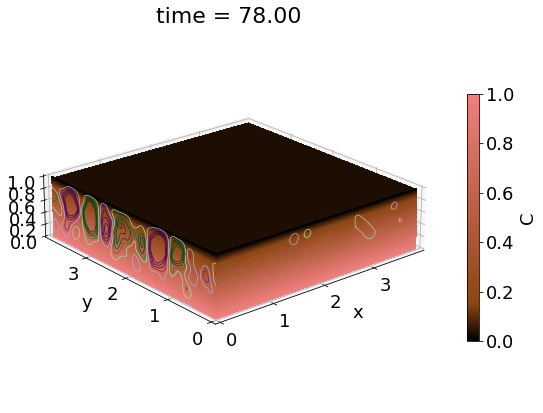

In [5]:
# ============================================================
# Run it here: all changes go here
# ============================================================

make_cube_slice_animation(
    snapshot_dir="snapshots_Le1_gamma01",
    file_prefix="snapshots_Le1_gamma01_s",
    output_name="mantle3D_cube_Le1_Cvort.gif",

    C_task="C",
    C_vmin=0,
    C_vmax=1,

    z_index = 64-8,
    y_index = 0,
    x_index = 0,

    Vtask_xy="vorticity_z",
    Vtask_xz="vorticity_y",
    Vtask_yz="vorticity_x",

    V_levels_base=np.asarray([
        -0.25, -0.2, -0.15, -0.1, -0.05,
         0.05,  0.1,  0.15,  0.2,  0.25
    ]),

    Vscale_factor=0.8,
    Vcolor_clip_fraction=0.1,
    V_cmap_name="PRGn",

    fps=4,
    framecutoff=40,
    dpi=150,
    figsize=(9, 7),
    elev=22, #higher means more top down view
    azim=-130, #angle of view (where 0 means looking down y axis toward negative y at xz plane)
)

<ipython-input-3-4f165a0afb3c>:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  contour_cmap = cm.get_cmap(V_cmap_name)


Found 8 snapshot files.
Scanning snapshots_Le10_gamma1/snapshots_Le10_gamma1_s1.h5
Scanning snapshots_Le10_gamma1/snapshots_Le10_gamma1_s2.h5
Scanning snapshots_Le10_gamma1/snapshots_Le10_gamma1_s3.h5
Scanning snapshots_Le10_gamma1/snapshots_Le10_gamma1_s4.h5
Scanning snapshots_Le10_gamma1/snapshots_Le10_gamma1_s5.h5
Scanning snapshots_Le10_gamma1/snapshots_Le10_gamma1_s6.h5
Scanning snapshots_Le10_gamma1/snapshots_Le10_gamma1_s7.h5
Scanning snapshots_Le10_gamma1/snapshots_Le10_gamma1_s8.h5
Total animation frames: 74
Vscale = 1.695943e+02
Vscale2 = 1.695943e+02
Frame 1/74: snapshots_Le10_gamma1/snapshots_Le10_gamma1_s1.h5, index 0, time 0.00
Frame 1/74: snapshots_Le10_gamma1/snapshots_Le10_gamma1_s1.h5, index 0, time 0.00
Frame 2/74: snapshots_Le10_gamma1/snapshots_Le10_gamma1_s1.h5, index 1, time 0.11
Frame 3/74: snapshots_Le10_gamma1/snapshots_Le10_gamma1_s1.h5, index 2, time 0.11
Frame 4/74: snapshots_Le10_gamma1/snapshots_Le10_gamma1_s1.h5, index 3, time 0.12
Frame 5/74: snapshots_

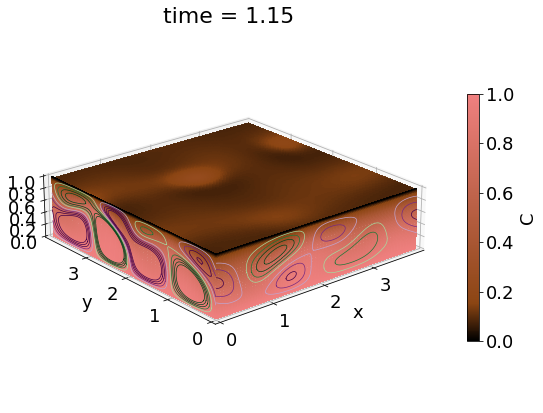

In [6]:
# ============================================================
# Run it here: all changes go here
# ============================================================

make_cube_slice_animation(
    snapshot_dir="snapshots_Le10_gamma1",
    file_prefix="snapshots_Le10_gamma1_s",
    output_name="mantle3D_cube_Le10_Cvort.gif",

    C_task="C",
    C_vmin=0,
    C_vmax=1,

    z_index = 64-8,
    y_index = 0,
    x_index = 0,

    Vtask_xy="vorticity_z",
    Vtask_xz="vorticity_y",
    Vtask_yz="vorticity_x",

    V_levels_base=np.asarray([
        -0.25, -0.2, -0.15, -0.1, -0.05,
         0.05,  0.1,  0.15,  0.2,  0.25
    ]),

    Vscale_factor=0.8,
    Vcolor_clip_fraction=0.1,
    V_cmap_name="PRGn",

    fps=4,
#    framecutoff=40,
    dpi=150,
    figsize=(9, 7),
    elev=22, #higher means more top down view
    azim=-130, #angle of view (where 0 means looking down y axis toward negative y at xz plane)
)

<ipython-input-6-66f0432fa375>:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  C_cmap = cm.get_cmap(C_cmap)
<ipython-input-6-66f0432fa375>:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  contour_cmap = cm.get_cmap(V_cmap_name)


Found 16 snapshot files.
Scanning snapshots/snapshots_s1.h5
Scanning snapshots/snapshots_s2.h5
Scanning snapshots/snapshots_s3.h5
Scanning snapshots/snapshots_s4.h5
Scanning snapshots/snapshots_s5.h5
Scanning snapshots/snapshots_s6.h5
Scanning snapshots/snapshots_s7.h5
Scanning snapshots/snapshots_s8.h5
Scanning snapshots/snapshots_s9.h5
Scanning snapshots/snapshots_s10.h5
Scanning snapshots/snapshots_s11.h5
Scanning snapshots/snapshots_s12.h5
Scanning snapshots/snapshots_s13.h5
Scanning snapshots/snapshots_s14.h5
Scanning snapshots/snapshots_s15.h5
Scanning snapshots/snapshots_s16.h5
Total animation frames: 156
Vscale = 1.093126e+00
Vscale2 = 1.093126e+00
Frame 1/156: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 1/156: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 2/156: snapshots/snapshots_s1.h5, index 1, time 0.10
Frame 3/156: snapshots/snapshots_s1.h5, index 2, time 0.10
Frame 4/156: snapshots/snapshots_s1.h5, index 3, time 0.10
Frame 5/156: snapshots/snapshots_s1.h5, 

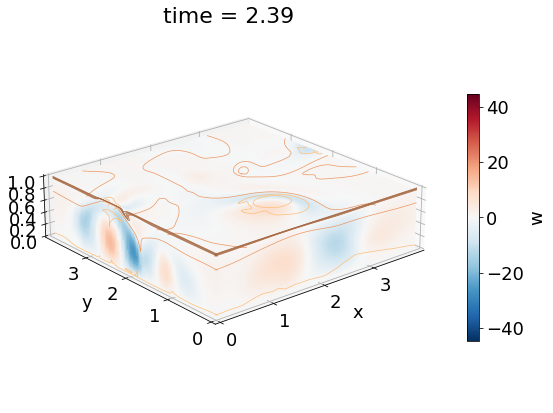

In [14]:
# ============================================================
# Run it here: all changes go here
# ============================================================

make_cube_slice_animation(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    output_name="mantle3D_cube_wC.gif",

    C_task="w",
    C_cmap="RdBu_r",

    z_index = -10,
    y_index = 1,
    x_index = 1,

    Vtask_xy="C",
    Vtask_xz="C",
    Vtask_yz="C",

    V_levels_base=np.asarray([
        0.02, 0.04, 0.06, 0.08, 0.1,0.5,0.9
    ]),

    Vscale_factor=1.0,
    Vcolor_clip_fraction=1.0,
    V_cmap_name="copper",

    fps=4,
#    framecutoff=2,
    dpi=150,
    figsize=(9, 7),
    elev=22, #higher means more top down view
    azim=-130, #angle of view (where 0 means looking down y axis toward negative y at xz plane)
)

Found 9 snapshot files.
Scanning snapshots/snapshots_s1.h5
Scanning snapshots/snapshots_s2.h5
Scanning snapshots/snapshots_s3.h5
Scanning snapshots/snapshots_s4.h5
Scanning snapshots/snapshots_s5.h5
Scanning snapshots/snapshots_s6.h5
Scanning snapshots/snapshots_s7.h5
Scanning snapshots/snapshots_s8.h5
Scanning snapshots/snapshots_s9.h5
Total animation frames: 85
w color limits: -4.9256e+00, 4.9256e+00
x shape: (128,) x min/max: 0.0 3.96875
y shape: (128,) y min/max: 0.0 3.96875
z shape: (64,) z min/max: 0.00015059065189787502 0.9998494093481021
plotting z = 0.9878510650192642
Frame 1/85: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 1/85: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 2/85: snapshots/snapshots_s1.h5, index 1, time 0.10
Frame 3/85: snapshots/snapshots_s1.h5, index 2, time 0.10
Frame 4/85: snapshots/snapshots_s1.h5, index 3, time 0.10
Frame 5/85: snapshots/snapshots_s1.h5, index 4, time 0.10
Frame 6/85: snapshots/snapshots_s1.h5, index 5, time 0.10
Frame 7/85

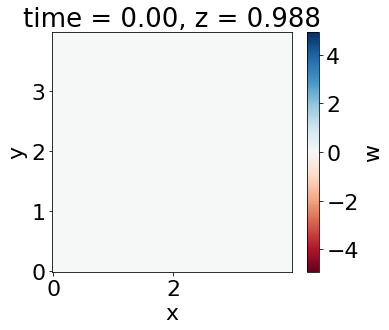

In [16]:
### MAKE ANIMATION OF LATERAL X-Y SLICE ###

# ----------------------------
# User settings
# ----------------------------
snapshot_dir = "snapshots"
file_prefix = "snapshots_s"
output_name = "mantle3D_xyperiodic_z-top_wC.gif"

z_index = -5          # fixed z-index for x-y slice
fps = 4
dpi = 150

C_levels = [0.25, 0.5, 0.75]  

# Brown -> olive -> green colormap
C_cmap = mcolors.LinearSegmentedColormap.from_list(
    "brown_to_green",
    ["saddlebrown", "olive", "forestgreen"]
)

C_colors = [C_cmap(i) for i in np.linspace(0, 1, len(C_levels))]

# Optional: set color limits manually, or leave as None
w_vmin = None
w_vmax = None

# ----------------------------
# Helper: get coordinate arrays from Dedalus HDF5 output
# ----------------------------
def get_coord(dset, dim_index):
    """
    Get coordinate scale from an HDF5 dataset dimension.
    For data shaped (t, nx, ny, nz):
        dim 0 = time
        dim 1 = x
        dim 2 = y
        dim 3 = z
    """
    keys = list(dset.dims[dim_index].keys())

    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")

    # Usually Dedalus stores the coordinate as the first/only scale.
    return np.asarray(dset.dims[dim_index][keys[0]])

# ----------------------------
# Find files in order
# ----------------------------
files = []
i = 1
while True:
    fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
    if os.path.exists(fname):
        files.append(fname)
        i += 1
    else:
        break

if len(files) == 0:
    raise FileNotFoundError(f"No files found like {snapshot_dir}/{file_prefix}X.h5")

print(f"Found {len(files)} snapshot files.")

# ----------------------------
# First pass: collect frame metadata and global w limits
# ----------------------------
frames = []

if w_vmin is None or w_vmax is None:
    global_min = np.inf
    global_max = -np.inf

for fname in files:
    print(f"Scanning {fname}")
    with h5py.File(fname, mode="r") as file:
        w_dset = file["tasks"]["w"]
        T_dset = file["tasks"]["T"]
        t = np.asarray(T_dset.dims[0]["sim_time"])

        nt = w_dset.shape[0]

        for it in range(nt):
            frames.append((fname, it, t[it]))

        if w_vmin is None or w_vmax is None:
            w_slice_all = np.asarray(w_dset[int(nt/2):, :, :, z_index])

            w_rms = np.sqrt(np.nanmean(w_slice_all**2))
            w_lim = 1.5 * w_rms

            global_min = min(global_min, -w_lim)
            global_max = max(global_max,  w_lim)

if w_vmin is None:
    w_vmin = global_min
if w_vmax is None:
    w_vmax = global_max

# Symmetric color scale about zero
w_abs = max(abs(w_vmin), abs(w_vmax))
w_vmin = -w_abs
w_vmax = w_abs

print(f"Total animation frames: {len(frames)}")
print(f"w color limits: {w_vmin:.4e}, {w_vmax:.4e}")

# ----------------------------
# Load first frame and actual coordinate arrays
# ----------------------------
first_fname, first_it, first_time = frames[0]

with h5py.File(first_fname, mode="r") as file:
    w_dset = file["tasks"]["w"]

    w0 = np.asarray(file["tasks"]["w"][first_it, :, :, z_index])
    C0 = np.asarray(file["tasks"]["C"][first_it, :, :, z_index])

    x = get_coord(w_dset, 1)
    y = get_coord(w_dset, 2)
    z = get_coord(w_dset, 3)

print("x shape:", x.shape, "x min/max:", x.min(), x.max())
print("y shape:", y.shape, "y min/max:", y.min(), y.max())
print("z shape:", z.shape, "z min/max:", z.min(), z.max())
print("plotting z =", z[z_index])

nx, ny = w0.shape

if len(x) != nx:
    raise ValueError(f"x coordinate length {len(x)} does not match nx {nx}")
if len(y) != ny:
    raise ValueError(f"y coordinate length {len(y)} does not match ny {ny}")

X, Y = np.meshgrid(x, y, indexing="ij")

# ----------------------------
# Figure setup
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

pcm = ax.pcolormesh(
    X, Y, w0,
    shading="auto",
    vmin=w_vmin,
    vmax=w_vmax,
    cmap="RdBu"
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("w")

contours = ax.contour(
    X, Y, C0,          
    levels=C_levels,
    colors=C_colors,
    linewidths=1.0,
)

ax.clabel(contours, inline=True, fontsize=8)

title = ax.set_title(f"time = {first_time:.2f}, z = {z[z_index]:.3g}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

plt.tight_layout()

# ----------------------------
# Animation update function
# ----------------------------
def update(frame_number):
    global contours

    fname, it, sim_time = frames[frame_number]

    with h5py.File(fname, mode="r") as file:
        w_slice = np.asarray(file["tasks"]["w"][it, :, :, z_index])
        C_slice = np.asarray(file["tasks"]["C"][it, :, :, z_index])

    pcm.set_array(w_slice.ravel())

    # Remove old contours
    for coll in contours.collections:
        coll.remove()

    # Draw new contours
    contours = ax.contour(
        X, Y, C_slice,      
        levels=C_levels,
        colors=C_colors,
        linewidths=1.0,
    )

    title.set_text(f"time = {sim_time:.2f}, z = {z[z_index]:.3g}")

    print(
        f"Frame {frame_number + 1}/{len(frames)}: "
        f"{fname}, index {it}, time {sim_time:.2f}"
    )

    return [pcm, title] + contours.collections

# ----------------------------
# Save animation
# ----------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False,
)

ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)

print(f"Saved animation to {output_name}")

Found 9 snapshot files.
Scanning snapshots/snapshots_s1.h5
Scanning snapshots/snapshots_s2.h5
Scanning snapshots/snapshots_s3.h5
Scanning snapshots/snapshots_s4.h5
Scanning snapshots/snapshots_s5.h5
Scanning snapshots/snapshots_s6.h5
Scanning snapshots/snapshots_s7.h5
Scanning snapshots/snapshots_s8.h5
Scanning snapshots/snapshots_s9.h5
Total animation frames: 85
w color limits: -6.5675e+00, 6.5675e+00
x shape: (128,) x min/max: 0.0 3.96875
y shape: (128,) y min/max: 0.0 3.96875
z shape: (64,) z min/max: 0.00015059065189787502 0.9998494093481021
plotting y = 2.0
Frame 1/85: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 1/85: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 2/85: snapshots/snapshots_s1.h5, index 1, time 0.10
Frame 3/85: snapshots/snapshots_s1.h5, index 2, time 0.10
Frame 4/85: snapshots/snapshots_s1.h5, index 3, time 0.10
Frame 5/85: snapshots/snapshots_s1.h5, index 4, time 0.10
Frame 6/85: snapshots/snapshots_s1.h5, index 5, time 0.10
Frame 7/85: snapshots/sna

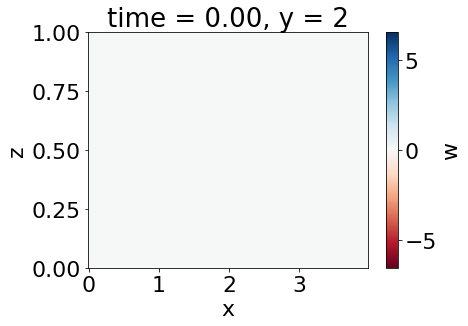

In [17]:
### MAKE ANIMATION OF VERTICAL X-Z SLICE ###

# ----------------------------
# User settings
# ----------------------------
snapshot_dir = "snapshots"
file_prefix = "snapshots_s"
output_name = "mantle3D_xyperiodic_y-64_wC.gif"

y_index = 64          # fixed y-index for x-z slice
fps = 4
dpi = 150

C_levels = [0.1, 0.3, 0.5, 0.7]  

# Brown -> olive -> green colormap
C_cmap = mcolors.LinearSegmentedColormap.from_list(
    "brown_to_green",
    ["saddlebrown", "olive", "forestgreen"]
)

C_colors = [C_cmap(i) for i in np.linspace(0, 1, len(C_levels))]

# Optional: set color limits manually, or leave as None
w_vmin = None
w_vmax = None

# ----------------------------
# Helper: get coordinate arrays from Dedalus HDF5 output
# ----------------------------
def get_coord(dset, dim_index):
    """
    Get coordinate scale from an HDF5 dataset dimension.
    For data shaped (t, nx, ny, nz):
        dim 0 = time
        dim 1 = x
        dim 2 = y
        dim 3 = z
    """
    keys = list(dset.dims[dim_index].keys())

    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")

    return np.asarray(dset.dims[dim_index][keys[0]])

# ----------------------------
# Find files in order
# ----------------------------
files = []
i = 1
while True:
    fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
    if os.path.exists(fname):
        files.append(fname)
        i += 1
    else:
        break

if len(files) == 0:
    raise FileNotFoundError(f"No files found like {snapshot_dir}/{file_prefix}X.h5")

print(f"Found {len(files)} snapshot files.")

# ----------------------------
# First pass: collect frame metadata and global w limits
# ----------------------------
frames = []

if w_vmin is None or w_vmax is None:
    global_min = np.inf
    global_max = -np.inf

for fname in files:
    print(f"Scanning {fname}")
    with h5py.File(fname, mode="r") as file:
        w_dset = file["tasks"]["w"]
        T_dset = file["tasks"]["T"]
        t = np.asarray(T_dset.dims[0]["sim_time"])

        nt = w_dset.shape[0]

        for it in range(nt):
            frames.append((fname, it, t[it]))

        if w_vmin is None or w_vmax is None:
            w_slice_all = np.asarray(w_dset[int(nt/2):, :, :, z_index])

            w_rms = np.sqrt(np.nanmean(w_slice_all**2))
            w_lim = 2.0 * w_rms

            global_min = min(global_min, -w_lim)
            global_max = max(global_max,  w_lim)

if w_vmin is None:
    w_vmin = global_min
if w_vmax is None:
    w_vmax = global_max

# Symmetric color scale about zero
w_abs = max(abs(w_vmin), abs(w_vmax))
w_vmin = -w_abs
w_vmax = w_abs

print(f"Total animation frames: {len(frames)}")
print(f"w color limits: {w_vmin:.4e}, {w_vmax:.4e}")

# ----------------------------
# Load first frame and actual coordinate arrays
# ----------------------------
first_fname, first_it, first_time = frames[0]

with h5py.File(first_fname, mode="r") as file:
    w_dset = file["tasks"]["w"]

    w0 = np.asarray(file["tasks"]["w"][first_it, :, y_index, :])
    C0 = np.asarray(file["tasks"]["C"][first_it, :, y_index, :])

    x = get_coord(w_dset, 1)
    y = get_coord(w_dset, 2)
    z = get_coord(w_dset, 3)

print("x shape:", x.shape, "x min/max:", x.min(), x.max())
print("y shape:", y.shape, "y min/max:", y.min(), y.max())
print("z shape:", z.shape, "z min/max:", z.min(), z.max())
print("plotting y =", y[y_index])

nx, nz = w0.shape

if len(x) != nx:
    raise ValueError(f"x coordinate length {len(x)} does not match nx {nx}")
if len(z) != nz:
    raise ValueError(f"z coordinate length {len(z)} does not match nz {nz}")

X, Z = np.meshgrid(x, z, indexing="ij")

# ----------------------------
# Figure setup
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    X, Z, w0,
    shading="auto",
    vmin=w_vmin,
    vmax=w_vmax,
    cmap="RdBu"
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("w")

contours = ax.contour(
    X, Z, C0,
    levels=C_levels,
    colors=C_colors,
    linewidths=0.8,
)

ax.clabel(contours, inline=True, fontsize=8)

title = ax.set_title(f"time = {first_time:.2f}, y = {y[y_index]:.3g}")
ax.set_xlabel("x")
ax.set_ylabel("z")

# If z=0 is bottom, leave this commented.
# If your plots look upside down, uncomment it.
# ax.invert_yaxis()

plt.tight_layout()

# ----------------------------
# Animation update function
# ----------------------------
def update(frame_number):
    global contours

    fname, it, sim_time = frames[frame_number]

    with h5py.File(fname, mode="r") as file:
        w_slice = np.asarray(file["tasks"]["w"][it, :, y_index, :])
        C_slice = np.asarray(file["tasks"]["C"][it, :, y_index, :])

    pcm.set_array(w_slice.ravel())

    # Remove old contours
    for coll in contours.collections:
        coll.remove()

    # Draw new contours
    contours = ax.contour(
        X, Z, C_slice,
        levels=C_levels,
        colors=C_colors,
        linewidths=0.8,
    )

    title.set_text(f"time = {sim_time:.2f}, y = {y[y_index]:.3g}")

    print(
        f"Frame {frame_number + 1}/{len(frames)}: "
        f"{fname}, index {it}, time {sim_time:.2f}"
    )

    return [pcm, title] + contours.collections

# ----------------------------
# Save animation
# ----------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False,
)

ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)

print(f"Saved animation to {output_name}")

Found 9 snapshot files.
Scanning snapshots/snapshots_s1.h5
Scanning snapshots/snapshots_s2.h5
Scanning snapshots/snapshots_s3.h5
Scanning snapshots/snapshots_s4.h5
Scanning snapshots/snapshots_s5.h5
Scanning snapshots/snapshots_s6.h5
Scanning snapshots/snapshots_s7.h5
Scanning snapshots/snapshots_s8.h5
Scanning snapshots/snapshots_s9.h5


<ipython-input-32-5bb9101c5baf>:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  contour_cmap = cm.get_cmap("RdBu")


Total animation frames: 89
x shape: (128,) x min/max: 0.0 3.96875
y shape: (128,) y min/max: 0.0 3.96875
z shape: (64,) z min/max: 0.00015059065189787502 0.9998494093481021
plotting y = 2.0
Frame 1/89: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 1/89: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 2/89: snapshots/snapshots_s1.h5, index 1, time 0.10
Frame 3/89: snapshots/snapshots_s1.h5, index 2, time 0.10
Frame 4/89: snapshots/snapshots_s1.h5, index 3, time 0.10
Frame 5/89: snapshots/snapshots_s1.h5, index 4, time 0.10
Frame 6/89: snapshots/snapshots_s1.h5, index 5, time 0.10
Frame 7/89: snapshots/snapshots_s1.h5, index 6, time 0.10
Frame 8/89: snapshots/snapshots_s1.h5, index 7, time 0.10
Frame 9/89: snapshots/snapshots_s1.h5, index 8, time 0.11
Frame 10/89: snapshots/snapshots_s1.h5, index 9, time 0.11
Frame 11/89: snapshots/snapshots_s2.h5, index 0, time 0.11
Frame 12/89: snapshots/snapshots_s2.h5, index 1, time 0.11
Frame 13/89: snapshots/snapshots_s2.h5, index 2, time

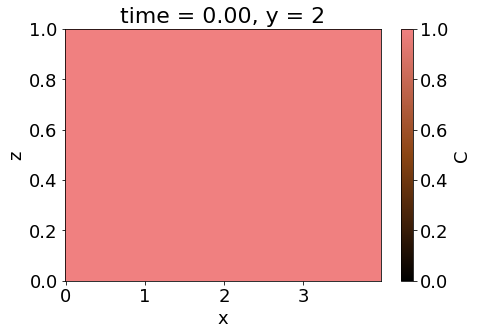

In [32]:
### MAKE ANIMATION OF VERTICAL X-Z SLICE ###

# ----------------------------
# User settings
# ----------------------------
snapshot_dir = "snapshots"
file_prefix = "snapshots_s"
output_name = "mantle3D_xyperiodic_y-64_Cvort.gif"

y_index = 64          # fixed y-index for x-z slice
fps = 4
dpi = 150

V_levels = np.asarray([-0.25,-0.2,-0.15,-0.1,-0.05,0.05,0.1,0.15,0.2,0.25])

C_cmap = mcolors.LinearSegmentedColormap.from_list(
    "brown_to_red",
    ["black", "saddlebrown", "lightcoral"]
)

C_vmin = 0
C_vmax = 1

# ----------------------------
# Helper: get coordinate arrays from Dedalus HDF5 output
# ----------------------------
def get_coord(dset, dim_index):
    """
    Get coordinate scale from an HDF5 dataset dimension.
    For data shaped (t, nx, ny, nz):
        dim 0 = time
        dim 1 = x
        dim 2 = y
        dim 3 = z
    """
    keys = list(dset.dims[dim_index].keys())

    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")

    return np.asarray(dset.dims[dim_index][keys[0]])

# ----------------------------
# Find files in order
# ----------------------------
files = []
i = 1
while True:
    fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
    if os.path.exists(fname):
        files.append(fname)
        i += 1
    else:
        break

if len(files) == 0:
    raise FileNotFoundError(f"No files found like {snapshot_dir}/{file_prefix}X.h5")

print(f"Found {len(files)} snapshot files.")

# ----------------------------
# First pass: collect frame metadata and global V limits
# ----------------------------
frames = []
Vmax_frames = []

for fname in files:
    print(f"Scanning {fname}")
    with h5py.File(fname, mode="r") as file:
        V_dset = file["tasks"]["vorticity_y"]
        t = np.asarray(V_dset.dims[0]["sim_time"])
        nt = V_dset.shape[0]

        for it in range(nt):
            frames.append((fname, it, t[it]))
            Vmax_frames.append(np.nanmax(np.abs(V_dset[it, ...])))

Vscale = np.nanmax(Vmax_frames[len(Vmax_frames)//2:])
V_levels *= 0.8*Vscale

contour_cmap = cm.get_cmap("RdBu")
contour_norm = mcolors.Normalize(vmin=-Vscale/10, vmax=Vscale/10, clip=True)

V_colors = [contour_cmap(contour_norm(level)) for level in V_levels]

print(f"Total animation frames: {len(frames)}")

# ----------------------------
# Load first frame and actual coordinate arrays
# ----------------------------
first_fname, first_it, first_time = frames[0]

with h5py.File(first_fname, mode="r") as file:
    C_dset = file["tasks"]["C"]

    C0 = np.asarray(file["tasks"]["C"][first_it, :, y_index, :])
    V0 = np.asarray(file["tasks"]["vorticity_y"][first_it, :, y_index, :])

    x = get_coord(C_dset, 1)
    y = get_coord(C_dset, 2)
    z = get_coord(C_dset, 3)

print("x shape:", x.shape, "x min/max:", x.min(), x.max())
print("y shape:", y.shape, "y min/max:", y.min(), y.max())
print("z shape:", z.shape, "z min/max:", z.min(), z.max())
print("plotting y =", y[y_index])

nx, nz = w0.shape

if len(x) != nx:
    raise ValueError(f"x coordinate length {len(x)} does not match nx {nx}")
if len(z) != nz:
    raise ValueError(f"z coordinate length {len(z)} does not match nz {nz}")

X, Z = np.meshgrid(x, z, indexing="ij")

# ----------------------------
# Figure setup
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    X, Z, C0,
    shading="auto",
    vmin=C_vmin,
    vmax=C_vmax,
    cmap=C_cmap
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("C")

contours = ax.contour(
    X, Z, V0,
    levels=V_levels,
    colors=V_colors,
    linewidths=0.8,
)

ax.clabel(contours, inline=True, fontsize=8)

title = ax.set_title(f"time = {first_time:.2f}, y = {y[y_index]:.3g}")
ax.set_xlabel("x")
ax.set_ylabel("z")

# If z=0 is bottom, leave this commented.
# If your plots look upside down, uncomment it.
# ax.invert_yaxis()

plt.tight_layout()

# ----------------------------
# Animation update function
# ----------------------------
def update(frame_number):
    global contours

    fname, it, sim_time = frames[frame_number]

    with h5py.File(fname, mode="r") as file:
        C_slice = np.asarray(file["tasks"]["C"][it, :, y_index, :])
        V_slice = np.asarray(file["tasks"]["vorticity_y"][it, :, y_index, :])

    pcm.set_array(C_slice.ravel())

    # Remove old contours
    for coll in contours.collections:
        coll.remove()

    # Draw new contours
    contours = ax.contour(
        X, Z, V_slice,
        levels=V_levels,
        colors=V_colors,
        linewidths=0.8,
    )

    title.set_text(f"time = {sim_time:.2f}, y = {y[y_index]:.3g}")

    print(
        f"Frame {frame_number + 1}/{len(frames)}: "
        f"{fname}, index {it}, time {sim_time:.2f}"
    )

    return [pcm, title] + contours.collections

# ----------------------------
# Save animation
# ----------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False,
)

ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)

print(f"Saved animation to {output_name}")

Loaded KE from stdout:
KE_times shape: (893,)
KE shape: (893,)
KE time range: 0.02 1.607524
Loading T snapshots...
snapshots/snapshots_s1.h5
snapshots/snapshots_s2.h5
snapshots/snapshots_s3.h5
snapshots/snapshots_s4.h5
snapshots/snapshots_s5.h5
snapshots/snapshots_s6.h5
snapshots/snapshots_s7.h5
snapshots/snapshots_s8.h5
snapshots/snapshots_s9.h5
snapshots/snapshots_s10.h5
snapshots/snapshots_s11.h5
snapshots/snapshots_s12.h5
snapshots/snapshots_s13.h5
snapshots/snapshots_s14.h5
snapshots/snapshots_s15.h5
snapshots/snapshots_s16.h5
snapshots/snapshots_s17.h5
T_times shape: (168,)
Tbar_profiles shape: (168, 64)
z_T shape: (64,)
Loading nonlinear diagnostics...
snapshots_nonlinear/snapshots_nonlinear_s1.h5
snapshots_nonlinear/snapshots_nonlinear_s2.h5
snapshots_nonlinear/snapshots_nonlinear_s3.h5
snapshots_nonlinear/snapshots_nonlinear_s4.h5
snapshots_nonlinear/snapshots_nonlinear_s5.h5
snapshots_nonlinear/snapshots_nonlinear_s6.h5
snapshots_nonlinear/snapshots_nonlinear_s7.h5
snapshots_

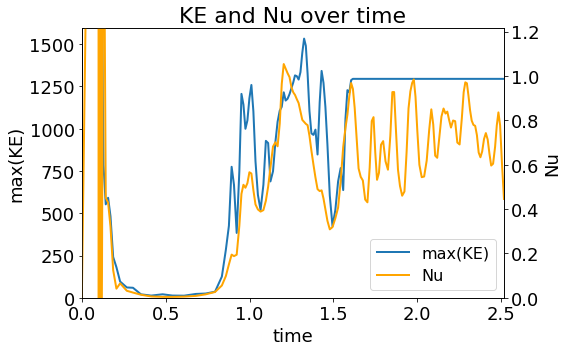

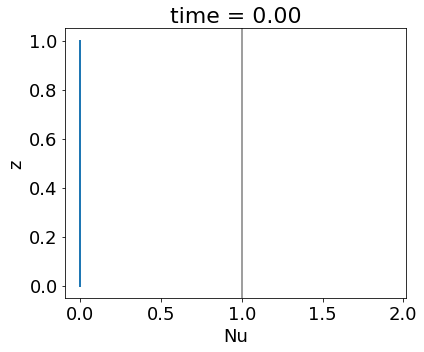

In [5]:
### Nu and KE ANALYSIS ###

# ============================================================
# User settings
# ============================================================
snap_dir = "snapshots"
nonlinear_dir = "snapshots_nonlinear"

# stdout / log file containing lines with max(KE)=...
stdout_file = "stdout.531863"

output_timeseries = "KE_Nu_base.png"
output_gif = "Nu_zprof_base.gif"

fps = 6
dpi = 150

# ============================================================
# Helpers
# ============================================================
def natural_sort_key(path):
    return [int(s) if s.isdigit() else s for s in re.split(r"(\d+)", path)]

def get_h5_files(folder):
    files = sorted(glob.glob(os.path.join(folder, "*.h5")), key=natural_sort_key)
    if len(files) == 0:
        raise FileNotFoundError(f"No .h5 files found in {folder}")
    return files

def get_time_from_task(dset):
    return np.asarray(dset.dims[0]["sim_time"])

def get_coord(dset, dim_index):
    keys = list(dset.dims[dim_index].keys())
    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")
    return np.asarray(dset.dims[dim_index][keys[0]])

def squeeze_task(arr):
    return np.squeeze(np.asarray(arr))

def load_ke_from_stdout(stdout_file):
    """
    Extract Time and max(KE) from lines like:

    Iteration=621, Time=1.035369e-01, dt=9.722929e-06, max(KE)=114422.473896
    """
    times = []
    kes = []

    pattern = re.compile(
        r"Time=([+-]?\d+(?:\.\d*)?(?:[eE][+-]?\d+)?).*?"
        r"max\(KE\)=([+-]?\d+(?:\.\d*)?(?:[eE][+-]?\d+)?)"
    )

    with open(stdout_file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match is not None:
                times.append(float(match.group(1)))
                kes.append(float(match.group(2)))

    if len(times) == 0:
        raise ValueError(f"No KE lines found in {stdout_file}")

    times = np.asarray(times)
    kes = np.asarray(kes)

    order = np.argsort(times)
    return times[order], kes[order]

def pad_limits(vmin, vmax, frac=0.05):
    pad = frac * (vmax - vmin)
    if pad == 0 or not np.isfinite(pad):
        center = 0.5 * (vmin + vmax)
        pad = frac * abs(center)
        if pad == 0 or not np.isfinite(pad):
            pad = frac
    return vmin - pad, vmax + pad

# ============================================================
# Load KE from stdout
# ============================================================
KE_times_raw, KE_raw = load_ke_from_stdout(stdout_file)

print("Loaded KE from stdout:")
print("KE_times shape:", KE_times_raw.shape)
print("KE shape:", KE_raw.shape)
print("KE time range:", KE_times_raw.min(), KE_times_raw.max())

# ============================================================
# Load T snapshots and compute horizontally averaged T(z,t)
# ============================================================
snap_files = get_h5_files(snap_dir)

T_times = []
Tbar_profiles = []

z_T = None

print("Loading T snapshots...")

for fname in snap_files:
    print(fname)
    with h5py.File(fname, "r") as f:
        T_dset = f["tasks"]["T"]
        t = get_time_from_task(T_dset)
        T = np.asarray(T_dset)  # expected shape: (t, nx, ny, nz)

        if z_T is None:
            z_T = get_coord(T_dset, 3)

        # horizontally averaged T(z)
        Tbar = np.nanmean(T, axis=(1, 2))  # shape: (nt, nz)

        T_times.append(t)
        Tbar_profiles.append(Tbar)

T_times = np.concatenate(T_times)
Tbar_profiles = np.concatenate(Tbar_profiles, axis=0)

order = np.argsort(T_times)
T_times = T_times[order]
Tbar_profiles = Tbar_profiles[order, :]

print("T_times shape:", T_times.shape)
print("Tbar_profiles shape:", Tbar_profiles.shape)
print("z_T shape:", z_T.shape)

# ============================================================
# Load nonlinear diagnostics: convective_heat_flux_z
# ============================================================
nonlinear_files = get_h5_files(nonlinear_dir)

chf_times = []
chf_profiles = []

z_chf = None

print("Loading nonlinear diagnostics...")

for fname in nonlinear_files:
    print(fname)
    with h5py.File(fname, "r") as f:
        chf_dset = f["tasks"]["convective_heat_flux_z"]
        t_chf = get_time_from_task(chf_dset)
        chf = squeeze_task(chf_dset)

        if z_chf is None:
            z_chf = get_coord(chf_dset, 1)

        chf_times.append(t_chf)
        chf_profiles.append(chf)

chf_times = np.concatenate(chf_times)
chf_profiles = np.concatenate(chf_profiles, axis=0)

order = np.argsort(chf_times)
chf_times = chf_times[order]
chf_profiles = chf_profiles[order, :]

print("chf_times shape:", chf_times.shape)
print("chf_profiles shape:", chf_profiles.shape)
print("z_chf shape:", z_chf.shape)

# ============================================================
# Compute Nu at each T snapshot time
# ============================================================
Nu_times = []
Nu_profiles = []
Nu_global = []

for i, t0 in enumerate(T_times):
    # interval around this T sample
    if i == 0:
        t_left = -np.inf
    else:
        t_left = 0.5 * (T_times[i - 1] + T_times[i])

    if i == len(T_times) - 1:
        t_right = np.inf
    else:
        t_right = 0.5 * (T_times[i] + T_times[i + 1])

    mask = (chf_times >= t_left) & (chf_times < t_right)

    if not np.any(mask):
        # fallback: nearest convective heat flux sample
        j = np.argmin(np.abs(chf_times - t0))
        chf_mean_z = chf_profiles[j, :]
    else:
        chf_mean_z = np.nanmean(chf_profiles[mask, :], axis=0)

    Tbar_z = Tbar_profiles[i, :]

    dTdz = np.gradient(Tbar_z, z_T, edge_order=2)

    # Requested definition:
    # Nu(z) = <wT>_xy / (-d<T>_xy/dz)
    Nu_z = chf_mean_z / (-dTdz)

    Nu_times.append(t0)
    Nu_profiles.append(Nu_z)

    Nu_mean = np.trapz(Nu_z, z_T) / (z_T[-1] - z_T[0])
    Nu_global.append(Nu_mean)

Nu_times = np.asarray(Nu_times)
Nu_profiles = np.asarray(Nu_profiles)
Nu_global = np.asarray(Nu_global)

print("Nu_times shape:", Nu_times.shape)
print("Nu_profiles shape:", Nu_profiles.shape)
print("Nu_global shape:", Nu_global.shape)

# ============================================================
# Sample/interpolate KE onto Nu times
# ============================================================
# This gives KE with exactly as many points as Nu.
KE_at_Nu_times = np.interp(Nu_times, KE_times_raw, KE_raw)

if Nu_times.min() < KE_times_raw.min() or Nu_times.max() > KE_times_raw.max():
    print("WARNING: Nu time range extends outside KE stdout time range.")
    print("         np.interp used endpoint KE values outside available KE range.")

# ============================================================
# Last quarter samples for axis limits
# ============================================================
n_samples = len(Nu_times)
iq0 = int(0.5 * n_samples)

Nu_times_lq = Nu_times[iq0:]
Nu_profiles_lq = Nu_profiles[iq0:, :]
Nu_global_lq = Nu_global[iq0:]
KE_lq = KE_at_Nu_times[iq0:]

print(f"Using samples {iq0} through {n_samples - 1} for axis limits.")

# ============================================================
# Plot KE and Nu time series with two y axes
# Axis limits based only on last quarter of samples
# ============================================================
fig, ax1 = plt.subplots(figsize=(8, 5))

line1, = ax1.plot(Nu_times, KE_at_Nu_times, linewidth=2, label="max(KE)")
ax1.set_xlabel("time")
ax1.set_ylabel("max(KE)")

ax2 = ax1.twinx()
line2, = ax2.plot(Nu_times, Nu_global, linewidth=2, color='orange', label="Nu")
ax2.set_ylabel("Nu")

# Show full time range, but scale y-limits from last quarter only.
ax1.set_xlim(Nu_times.min(), Nu_times.max())

KE_ymin, KE_ymax = pad_limits(np.nanmin(KE_lq), np.nanmax(KE_lq))
Nu_ymin, Nu_ymax = pad_limits(np.nanmin(Nu_global_lq), np.nanmax(Nu_global_lq))

ax1.set_ylim(0, 1.2*KE_ymax)
ax2.set_ylim(0, 1.2*Nu_ymax)

ax1.set_title("KE and Nu over time")

lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

fig.tight_layout()
fig.savefig(output_timeseries, dpi=dpi)
print(f"Saved {output_timeseries}")

# ============================================================
# GIF: Nu(z) only
# Axis limits based only on last quarter of profiles
# ============================================================
Nu_vmin = np.nanpercentile(Nu_profiles_lq, 1)
Nu_vmax = np.nanpercentile(Nu_profiles_lq, 99)
Nu_vmin, Nu_vmax = pad_limits(Nu_vmin, Nu_vmax)

fig, ax = plt.subplots(figsize=(6, 5))

line_Nu, = ax.plot(Nu_profiles[0, :], z_T, linewidth=2)

ax.axvline(1,color="gray",zorder=-1)
ax.set_xlabel("Nu")
ax.set_ylabel("z")
ax.set_xlim(Nu_vmin, Nu_vmax)
ax.set_title(f"time = {Nu_times[0]:.2f}")

# For usual Dedalus z=0 bottom, Lz top, leave this commented.
# ax.invert_yaxis()

fig.tight_layout()

def update(frame):
    line_Nu.set_xdata(Nu_profiles[frame, :])
    ax.set_title(f"time = {Nu_times[frame]:.2f}")

    print(f"GIF frame {frame + 1}/{len(Nu_times)}: time = {Nu_times[frame]:.2f}")

    return [line_Nu]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(Nu_times),
    interval=1000 / fps,
    blit=False,
)

ani.save(output_gif, writer="pillow", fps=fps, dpi=dpi)
print(f"Saved {output_gif}")